# Decoder attention (Qwen) vs. IRT difficulty

`entropy_manual_review.ipynb` found attention entropy unreliable as a difficulty signal for
extractive/T5 QA models -- but never tried a real generative decoder-only model. This notebook
does that with `DecoderOnlyQAModel` (`question_answering/qa_model.py`) -- same shared interface
as the encoder/T5 classes, so it reuses the same manual-inspection visualizer
(`question_answering/attention_inspection.py`) -- and correlates both attention entropy and the
model's own MC accuracy against the IRT (Rasch) item difficulty from
`question_difficulty_with_irt.ipynb` (real human response data).

## Contents

0. [Imports and paths](#imports)
1. [Load items + IRT difficulty ground truth](#load)
2. [Load the Qwen model](#model)
3. [General info: model accuracy (batch)](#general-info)
4. [Manual inspection (qualitative)](#manual)
5. [Correlate with IRT difficulty](#correlate)

<a id="imports"></a>
## 0. Imports and paths

In [8]:
import json
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent.parent
ONESTOPQA_REPO = REPO_ROOT.parent / "onestop-qa"
RASCH_DIFFICULTY_CACHE = Path("irt_rasch_difficulty_cache.json")
assert ONESTOPQA_REPO.exists(), f"expected onestop-qa clone at {ONESTOPQA_REPO}"
assert RASCH_DIFFICULTY_CACHE.exists(), (
    f"{RASCH_DIFFICULTY_CACHE} not found -- run question_difficulty_with_irt.ipynb's "
    "IRT section first, it writes this cache"
)

sys.path.insert(0, str(REPO_ROOT / "question_difficulty/methods/human_answer_based/irt"))
sys.path.insert(0, str(REPO_ROOT))
from data_processing import HumanResponseBank, _texts_match
from question_answering.qa_model import DecoderOnlyQAModel
from question_answering.attention_inspection import inspect_attention, inspect_question_token_attention

<a id="load"></a>
## 1. Load items + IRT difficulty ground truth

In [9]:
bank = HumanResponseBank(ONESTOPQA_REPO)
item_difficulty = json.load(open(RASCH_DIFFICULTY_CACHE))

# One record per item: passage, question, 4 options, correct answer, IRT difficulty.
# (paragraph/question/options are identical across every response row for a given
# item_id, so just take the first row seen.)
items = {}
for item_id, rows in bank.rows_by_item().items():
    if item_id not in item_difficulty:
        continue
    r = rows[0]
    items[item_id] = {
        "passage": r["paragraph"],
        "question": r["question"],
        "options": r["options"].split("|"),
        "correct_answer_text": r["correct_answer_text"],
        "difficulty": item_difficulty[item_id],
    }

print(f"{len(items)} items with both passage/question data and an IRT difficulty score")

1296 items with both passage/question data and an IRT difficulty score


<a id="model"></a>
## 2. Load the Qwen model

`DecoderOnlyQAModel` (in `question_answering/qa_model.py`, alongside `ExtractiveQAModel` and `GenerativeQAModel`) wraps loading, generation, and attention extraction behind the same interface those two already use -- so the rest of this notebook (and `inspect_attention`/`inspect_question_token_attention`) doesn't need to know or care that this one is a causal decoder.

Start with 0.5B to validate the pipeline; swap `MODEL_NAME` to `Qwen/Qwen2.5-1.5B-Instruct` for the real run once this works (18GB RAM locally, both fit easily).

In [10]:
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

model = DecoderOnlyQAModel(MODEL_NAME)
print(f"loaded {MODEL_NAME} on {model.device}, "
      f"{sum(p.numel() for p in model.model.parameters())/1e6:.0f}M params, "
      f"{model.model.config.num_hidden_layers} layers (default inspection layer: {model._default_layer()})")

loaded Qwen/Qwen2.5-0.5B-Instruct on mps, 494M params, 24 layers (default inspection layer: 23)


<a id="general-info"></a>
## 3. General info: model accuracy (batch)

For each of `N_ITEMS` sampled items, compute two independent numbers:

- **Accuracy signal**: `predict_multiple_choice_answer` -- the model actually picks a letter (A-D), checked against the item's real correct answer. Did the model get it right.
- **Entropy signal**: `get_attention_distribution` -- last layer, heads averaged, punctuation excluded (`entropy_norm_no_punct`). How spread-out the model's attention is.

Both get stored per item, plus `correct_ids`/`incorrect_ids` -- the item IDs split by whether the model got them right, so §4 (manual inspection) can pick specific examples from each bucket instead of an arbitrary item. §5 uses the same `results` to check whether either signal tracks the item's real (IRT) difficulty.

In [12]:
len(items)

1296

In [13]:
random.seed(0)
N_ITEMS = 40
sample_ids = random.sample(list(items.keys()), min(N_ITEMS, len(items)))

results = {}
for i, item_id in enumerate(sample_ids):
    it = items[item_id]
    letter, conf = model.predict_multiple_choice_answer(it["passage"], it["question"], it["options"])
    predicted_text = it["options"]["ABCD".index(letter)] if letter else None
    is_correct = _texts_match(predicted_text, it["correct_answer_text"]) if predicted_text else False
    detail = model.get_attention_distribution(it["passage"], it["question"])

    results[item_id] = {
        "letter": letter, "confidence": conf, "is_correct": is_correct,
        "entropy": detail["entropy_norm_no_punct"],
        "difficulty": it["difficulty"],
    }
    if (i + 1) % 10 == 0:
        print(f"{i+1}/{len(sample_ids)} done")

correct_ids = [item_id for item_id, r in results.items() if r["is_correct"]]
incorrect_ids = [item_id for item_id, r in results.items() if not r["is_correct"]]

print(f"\nmodel accuracy: {len(correct_ids)}/{len(results)} ({len(correct_ids)/len(results):.1%})")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/Users/anh-duc.vu/Personal/working-repos/revita/reading-question-generator/.venv/lib/python3.12/site-packages/transformers/pytorch_utils.py:339: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_elements = torch.tensor(test_elements)


10/40 done
20/40 done
30/40 done
40/40 done

model accuracy: 16/40 (40.0%)
correct_ids   (16): ['r2870_3_Middle', 'os5_1_2_Ele', 'r15113_2_High', 'r499_1_Middle', 'r6879_2_Middle', 'os5_4_2_Adv', 'r5351_1_High', 'os2_1_1_Ele', 'os19_5_1_Adv', 'os3_5_3_Ele', 'os15_2_3_Adv', 'os19_3_1_Ele', 'r6194_2_Middle', 'r7657_1_Middle', 'os5_1_1_Adv', 'os7_4_2_Adv']
incorrect_ids (24): ['os18_5_1_Ele', 'r1029_2_Middle', 'os7_2_1_Ele', 'os13_1_3_Ele', 'r8644_3_High', 'r6620_3_High', 'os12_1_3_Adv', 'r8075_3_High', 'r504_2_Middle', 'r4761_2_High', 'r3818_2_Middle', 'r1536_3_High', 'os20_3_3_Adv', 'r23185_1_High', 'os8_3_2_Adv', 'r5072_2_Middle', 'os8_3_1_Ele', 'r288_3_Middle', 'r7273_3_Middle', 'r6700_3_Middle', 'os3_5_1_Adv', 'r17195_1_High', 'r874_2_High', 'os3_2_1_Adv']


20/40 done


30/40 done


40/40 done

model accuracy: 16/40 (40.0%)
correct_ids   (16): ['r2870_3_Middle', 'os5_1_2_Ele', 'r15113_2_High', 'r499_1_Middle', 'r6879_2_Middle', 'os5_4_2_Adv', 'r5351_1_High', 'os2_1_1_Ele', 'os19_5_1_Adv', 'os3_5_3_Ele', 'os15_2_3_Adv', 'os19_3_1_Ele', 'r6194_2_Middle', 'r7657_1_Middle', 'os5_1_1_Adv', 'os7_4_2_Adv']
incorrect_ids (24): ['os18_5_1_Ele', 'r1029_2_Middle', 'os7_2_1_Ele', 'os13_1_3_Ele', 'r8644_3_High', 'r6620_3_High', 'os12_1_3_Adv', 'r8075_3_High', 'r504_2_Middle', 'r4761_2_High', 'r3818_2_Middle', 'r1536_3_High', 'os20_3_3_Adv', 'r23185_1_High', 'os8_3_2_Adv', 'r5072_2_Middle', 'os8_3_1_Ele', 'r288_3_Middle', 'r7273_3_Middle', 'r6700_3_Middle', 'os3_5_1_Adv', 'r17195_1_High', 'r874_2_High', 'os3_2_1_Adv']


<a id="manual"></a>
## 4. Manual inspection (qualitative)

Same visualizer used for the encoder/T5 models in `entropy_manual_review.ipynb` -- `inspect_attention` shows per-token and per-sentence attention highlighted directly on the passage; `inspect_question_token_attention` breaks it down per question word. Both read attention from Qwen's PREFILL pass only (see `DecoderOnlyQAModel`'s docstring) -- no generation happens for these two calls.

Pick any ID from `correct_ids` or `incorrect_ids` (built in §3) below to inspect a case the model got right vs. wrong.

In [15]:
_sample_id = correct_ids[1]   # swap for incorrect_ids[0], or any specific ID from either list
_sample = items[_sample_id]
print(f"item: {_sample_id}  (IRT difficulty={_sample['difficulty']:+.3f}, "
      f"model {'correct' if _sample_id in results and results[_sample_id]['is_correct'] else 'wrong'})")
print(f"gold answer: {_sample['correct_answer_text']!r}")
print("(note: the 'Predicted answer' below is free-text generation, not compared against "
      "the 4 options -- inspect_attention doesn't know about MC options at all. The real "
      "MC-with-options accuracy check happened in §3 via predict_multiple_choice_answer.)")

inspect_attention(_sample["passage"], _sample["question"], model=model)

item: os5_1_2_Ele  (IRT difficulty=-0.948, model correct)
gold answer: 'He disapproves of people who are OK with pirating'
(note: the 'Predicted answer' below is free-text generation, not compared against the 4 options -- inspect_attention doesn't know about MC options at all. The real MC-with-options accuracy check happened in §3 via predict_multiple_choice_answer.)
Question: 'What does Pullman think about pirating?'  (heads averaged)
Predicted answer: "Pullman believes that illegal downloading is morally wrong and theft, just like putting one's hand in someone else's pocket and stealing their wallet."  (confidence=0.705)
Sentence-level: entropy_norm=0.991  pr_norm=0.970  (3 sentences)
Token-level:    entropy_norm=0.906  pr_norm=0.508  (74 non-punctuation tokens, of 83 total)
--------------------------------------------------------------------------------
>>> Token-level attention (darker = more attention; punctuation tokens excluded):


--------------------------------------------------------------------------------
>>> Sentence-level attention (darker = more attention; punctuation tokens excluded):


In [16]:
inspect_question_token_attention(_sample["passage"], _sample["question"], model=model)

Question: 'What does Pullman think about pirating?'  (heads averaged)
--------------------------------------------------------------------------------
>>> Question token: ' does'


--------------------------------------------------------------------------------
>>> Question token: ' Pull'


--------------------------------------------------------------------------------
>>> Question token: 'man'


--------------------------------------------------------------------------------
>>> Question token: ' think'


--------------------------------------------------------------------------------
>>> Question token: ' about'


--------------------------------------------------------------------------------
>>> Question token: ' pir'


--------------------------------------------------------------------------------
>>> Question token: 'ating'


--------------------------------------------------------------------------------
>>> Question token: '?\n'


<a id="correlate"></a>
## 5. Correlate with IRT difficulty

Attention entropy vs. IRT difficulty:
  Pearson  r=-0.181  p=0.264
  Spearman r=-0.184  p=0.257

Mean IRT difficulty when model is correct: -0.408
Mean IRT difficulty when model is wrong:   +0.419


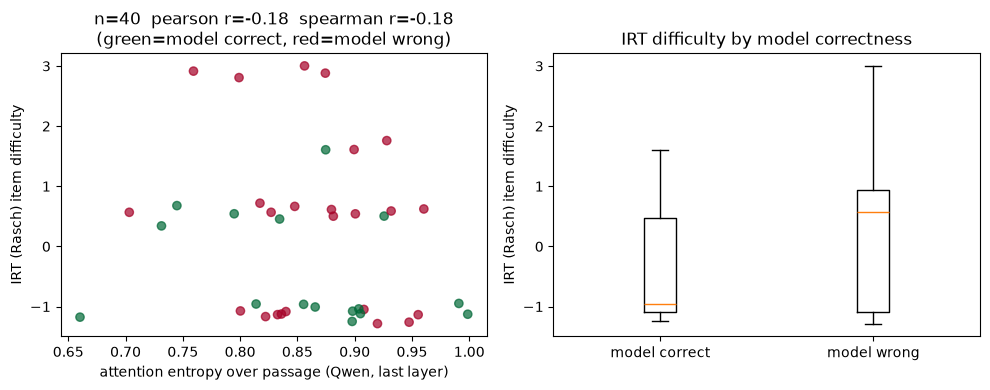

In [8]:
from scipy.stats import pearsonr, spearmanr

entropy_vals = np.array([r["entropy"] for r in results.values()])
difficulty_vals = np.array([r["difficulty"] for r in results.values()])
correct_vals = np.array([r["is_correct"] for r in results.values()])

pearson_r, pearson_p = pearsonr(entropy_vals, difficulty_vals)
spearman_r, spearman_p = spearmanr(entropy_vals, difficulty_vals)
print("Attention entropy vs. IRT difficulty:")
print(f"  Pearson  r={pearson_r:+.3f}  p={pearson_p:.3f}")
print(f"  Spearman r={spearman_r:+.3f}  p={spearman_p:.3f}")

# Sanity check: does the model's own accuracy actually drop on harder (per IRT) items?
mean_difficulty_correct = difficulty_vals[correct_vals].mean() if correct_vals.any() else float("nan")
mean_difficulty_wrong = difficulty_vals[~correct_vals].mean() if (~correct_vals).any() else float("nan")
print(f"\nMean IRT difficulty when model is correct: {mean_difficulty_correct:+.3f}")
print(f"Mean IRT difficulty when model is wrong:   {mean_difficulty_wrong:+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(entropy_vals, difficulty_vals, c=correct_vals, cmap="RdYlGn", alpha=0.7)
axes[0].set_xlabel("attention entropy over passage (Qwen, last layer)")
axes[0].set_ylabel("IRT (Rasch) item difficulty")
axes[0].set_title(f"n={len(results)}  pearson r={pearson_r:+.2f}  spearman r={spearman_r:+.2f}\n(green=model correct, red=model wrong)")

axes[1].boxplot([difficulty_vals[correct_vals], difficulty_vals[~correct_vals]],
                tick_labels=["model correct", "model wrong"])
axes[1].set_ylabel("IRT (Rasch) item difficulty")
axes[1].set_title("IRT difficulty by model correctness")

plt.tight_layout()
plt.show()